# Chicago 1918 fire data

In [2]:
# Import libraries
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import seaborn as sns
from libpysal import graph
from sklearn import cluster
from sklearn import preprocessing

# Read geojson
chifire = gpd.read_file("data/chicago_influenza_1918.geojson")

chifire.explore()

We still need to standardize the data columns such that they are centered aroudn 0. This means that for some categories, a negative number might not initially make sense

In [ ]:
# Standardizing the dataset
demographics = [
    "gross_acres",
    "illit",
    "unemployed_pct",
    "ho_pct",
    "agecat1",
    "agecat2",
    "agecat3",
    "agecat4",
    "agecat5",
    "agecat6",
    "agecat7",
]

chifire[demographics] = preprocessing.robust_scale(chifire[demographics])

In [10]:
# Exploring the first age category
chifire[["agecat1", "geometry"]].explore("agecat1", tiles="CartoDB Positron", tooltip=False)

In [9]:
# Exploring the unemployed percentage category
chifire[["unemployed_pct", "geometry"]].explore("unemployed_pct", tiles="CartoDB Positron", tooltip=False)

Now we can carry on with the analysis of the demographic data in the 1918 chicago fire.

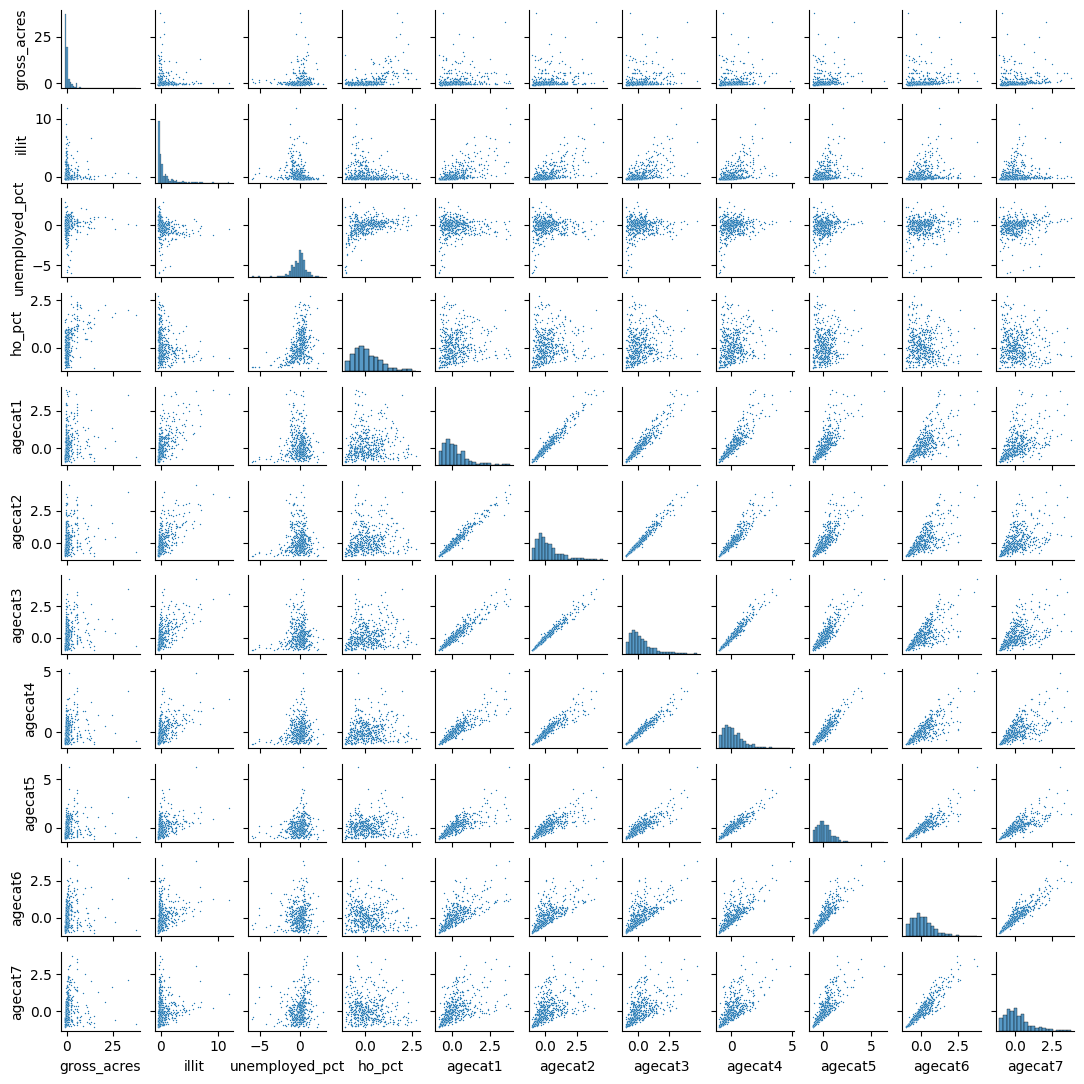

In [ ]:
# It is rather difficult to understand what is going on in this plot
_ = sns.pairplot(chifire[demographics], height=1, plot_kws={"s":1})

In [14]:
# K means clustering
kmeans6 = cluster.KMeans(n_clusters=6, random_state=42)
kmeans6.fit(chifire[demographics])

# We can then assign the points their specific k means cluster labels
chifire["kmeans_6"] = kmeans6.labels_

# Then show the clusters along the map - 6 clusters
chifire[["kmeans_6", "geometry"]].explore("kmeans_6", categorical=True, tiles="CartoDB Positron")

The above map appears to be too granular. It looks like there is an extra layer of detail that may not be necessary

In [15]:
# K means clustering
kmeans3 = cluster.KMeans(n_clusters=3, random_state=42)
kmeans3.fit(chifire[demographics])

# We can then assign the points their specific k means cluster labels
chifire["kmeans_3"] = kmeans3.labels_

# Then show the clusters along the map - 6 clusters
chifire[["kmeans_3", "geometry"]].explore("kmeans_3", categorical=True, tiles="CartoDB Positron")

We are still seeing that the clusters are not staying in the same geographic area. This data can use regionalisation

In [20]:
# Need to build a contiguity weights matrix
queen = graph.Graph.build_contiguity(chifire)

# Then a row-standardised matrix
queen_row = queen.transform("R")

# Need a lagged version of each of the sub-ranks as its own new column.
for column in demographics:
    chifire[column + "_lag"] = queen_row.lag(chifire[column])

# highlight the lagged columns
demographics_lag = [column + "_lag" for column in demographics]

# combine the list of original variables and those with a lag to make it easier to pass to k means cluster
demographics_spatial = demographics + demographics_lag

In [21]:
# create a new clustering model based on the spatially lagged
kmeans6_lag = cluster.KMeans(n_clusters=6, random_state=42)
kmeans6_lag.fit(chifire[demographics_spatial])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",6
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [22]:
# We can then assign the points their specific k means cluster labels
chifire["kmeans_6_lag"] = kmeans6_lag.labels_

# Then show the clusters along the map - 6 clusters
chifire[["kmeans_6_lag", "geometry"]].explore("kmeans_6_lag", categorical=True, tiles="CartoDB Positron")

the spatially lagged version is practically the same as previous 6 clusters. I do not see a material difference between the two

In [23]:
# Need to connect the clustering algorithm to a sparse array
agg5 = cluster.AgglomerativeClustering(n_clusters=6, connectivity=queen.sparse)
# fit to the data, NOT the lagged data
agg5.fit(chifire[demographics])

# We can then assign the points their specific k means cluster labels
chifire["spat_reg"] = agg5.labels_

# Then show the clusters along the map - 6 clusters
chifire[["spat_reg", "geometry"]].explore("spat_reg", categorical=True, tiles="CartoDB Positron")

Now we can see a much cleaner version of the clusters, where each cluster has its own little space, especially in the city center, where previous clusters would overlap considerably

In [25]:
# dissolving by categories
chifire_regions = chifire[["spat_reg", "geometry"]].dissolve("spat_reg")

# displays the clusters as one big region each
chifire_regions.reset_index().explore("spat_reg", categorical=True, tiles = "CartoDB Positron")